In [1]:
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from context_flux_no.simulations.pde.burgers import ViscousBurgers1D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField
from context_flux_no.waveforms.step import PeriodicRandomStepFunction1D


jax.config.update("jax_default_device", jax.devices("gpu")[4])

2026-05-02 17:00:45,736 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


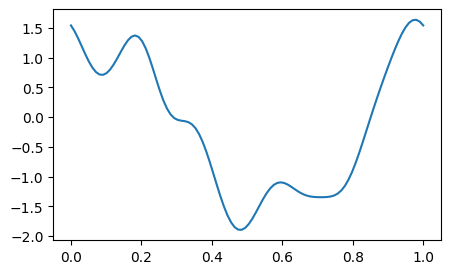

In [3]:
grf = GaussianRandomField(
    covariance_fns=[
        gs.Gaussian(dim=1, var=1.0, len_scale=0.1),
    ],
)
x = jnp.linspace(0, 1, 100)
u0 = grf.sample(x, jax.random.key(1))
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0[0])

In [19]:
u0.shape

(1, 100)

In [4]:
pde = ViscousBurgers1D(0.5586224794387817, 0.005106600467115641)
sol = pde.solve(
    lambda x: grf.sample(x, jax.random.key(1))[0],
    x_span=(0, 1),
    Nx=400,
    t_span=(0, 0.5),
    Nt=100,
    bc="periodic",
)

In [5]:
sol

<xarray.Dataset> Size: 327kB
Dimensions:  (ic: 1, t: 101, dim: 1, x: 400, param: 2)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 12B 'u_0'
  * x        (x) float64 3kB 0.0 0.0025 0.005 0.0075 ... 0.9925 0.995 0.9975
  * param    (param) <U1 8B 'a' 'b'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 323kB 1.543 1.522 1.499 ... 0.0 0.0 0.0
    coeffs   (param) float64 16B 0.5586 0.005107

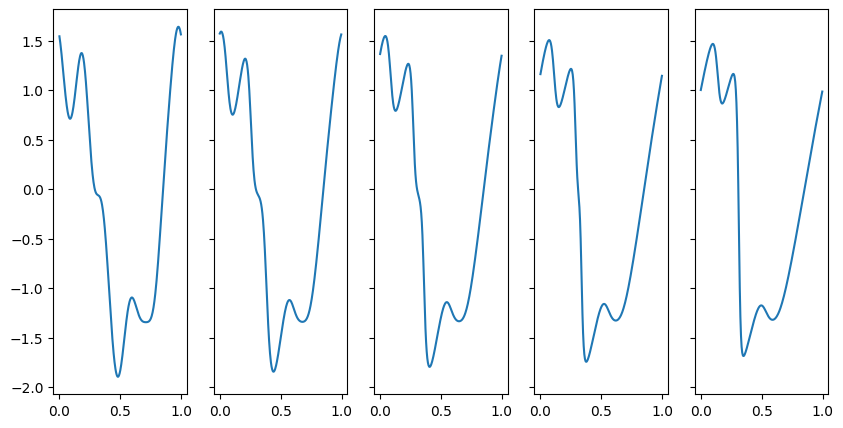

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(10, 5), sharey="row")
for i, ax in enumerate(axes):
    axes[i].plot(sol.coords["x"], sol["values"][0, 4 * i, 0])


In [7]:
dataset = generate_dataset(
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=ViscousBurgers1D,
    initial_condition_fn=GaussianRandomField(
        covariance_fns=[
            gs.Gaussian(dim=1, var=0.5, len_scale=0.3),
        ],
    ).sample,
    coeff_range_dict={
        "a": (0.5, 1.5),
        "b": (0.005, 0.015),
    },
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)

100%|██████████| 10/10 [01:37<00:00,  9.77s/it]
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/simulations/utils.py:70: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(solutions_all, "ic")  # "pde")


In [8]:
dataset

<xarray.Dataset> Size: 8MB
Dimensions:  (ic: 100, t: 101, dim: 1, x: 100, param: 2)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 12B 'u_0'
  * x        (x) float64 800B 0.0 0.01 0.02 0.03 0.04 ... 0.96 0.97 0.98 0.99
  * param    (param) <U1 8B 'a' 'b'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 8MB -0.3291 -0.3572 -0.3844 ... 0.0 0.0 0.0
    coeffs   (ic, param) float64 2kB 0.5586 0.005107 0.5586 ... 1.417 0.007107

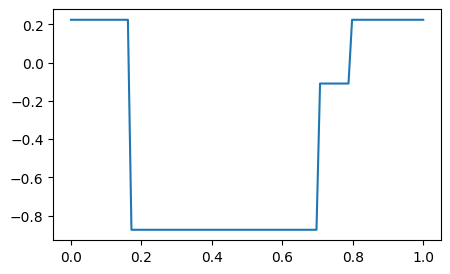

In [2]:
step = PeriodicRandomStepFunction1D()
x = jnp.linspace(0, 1, 100)
u0 = step.sample(x, jax.random.key(2))
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0[0])

In [3]:
pde = ViscousBurgers1D(0.5586224794387817, 0.005106600467115641)
sol = pde.solve(
    lambda x: step.sample(x, jax.random.key(2))[0],
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    bc="periodic",
)

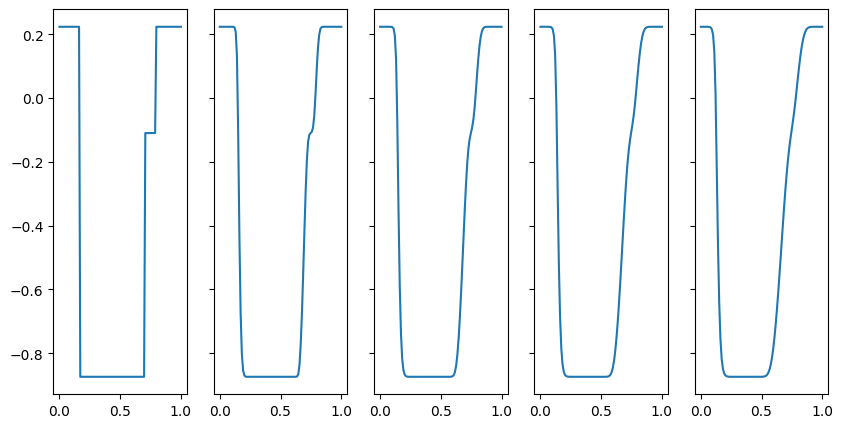

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(10, 5), sharey="row")
for i, ax in enumerate(axes):
    axes[i].plot(x, sol["values"][0, 4 * i, 0])


In [5]:
dataset = generate_dataset(
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=ViscousBurgers1D,
    initial_condition_fn=PeriodicRandomStepFunction1D().sample,
    coeff_range_dict={
        "a": (0.5, 1.5),
        "b": (0.005, 0.015),
    },
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)

100%|██████████| 10/10 [04:17<00:00, 25.72s/it]
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/simulations/utils.py:70: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(solutions_all, "ic")  # "pde")


In [6]:
dataset

<xarray.Dataset> Size: 8MB
Dimensions:  (ic: 100, t: 101, dim: 1, x: 100, param: 2)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 12B 'u_0'
  * x        (x) float64 800B 0.0 0.01 0.02 0.03 0.04 ... 0.96 0.97 0.98 0.99
  * param    (param) <U1 8B 'a' 'b'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 8MB 0.5167 0.5167 0.5167 ... 0.0 0.0 0.0
    coeffs   (ic, param) float64 2kB 0.5586 0.005107 0.5586 ... 1.417 0.007107